In [42]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
data = pd.read_csv("Supermarket.csv")

print(data.head())
print(data.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [44]:
print(data.isnull().sum())

data.dropna(inplace=True)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [46]:
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)
data["Ship Date"] = pd.to_datetime(data["Ship Date"], dayfirst=True)

In [47]:
data["Year"] = data["Order Date"].dt.year
data["Month"] = data["Order Date"].dt.month
data["Day"] = data["Order Date"].dt.day

In [50]:
print(data.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Day']


In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
    "Ship Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category"
]

for col in cols:
    data[col] = le.fit_transform(data[col])

In [57]:
X = data[
    [
        "Ship Mode",
        "Segment",
        "Country",
        "City",
        "State",
        "Region",
        "Category",
        "Sub-Category",
        "Year",
        "Month",
        "Day"
    ]
]

y = data["Sales"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [61]:
print(X.dtypes)

Ship Mode       int64
Segment         int64
Country         int64
City            int64
State           int64
Region          int64
Category        int64
Sub-Category    int64
Year            int32
Month           int32
Day             int32
dtype: object


In [63]:
predictions = model.predict(X_test)

print(predictions[:10])

[177.51034584 207.04015788 153.65537111 181.91261902 233.30886381
 228.86959314 200.45934777 204.64800474 178.86582086 183.07635168]


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 283.69706024891855
RMSE: 698.5030431641519
R² Score: 0.002508985802898156


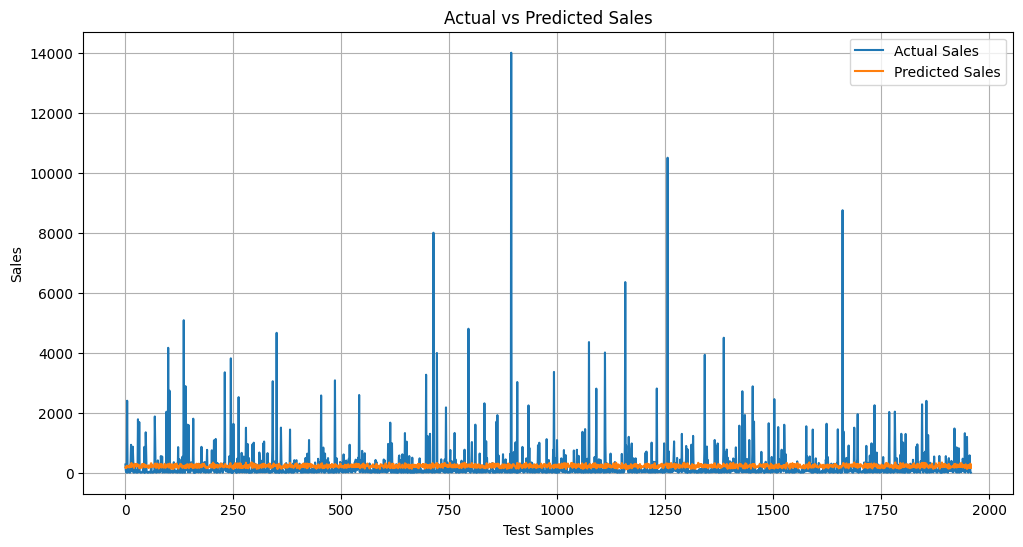

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
new_data = pd.DataFrame({
    "Ship Mode": [0],
    "Segment": [1],
    "Country": [0],
    "City": [10],
    "State": [5],
    "Region": [2],
    "Category": [1],
    "Sub-Category": [3],
    "Year": [2026],
    "Month": [7],
    "Day": [20]
})

future_prediction = model.predict(new_data)

print("Predicted Sales:", future_prediction[0])

Predicted Sales: 84.6079743554692


In [67]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R² Score:", r2_score(y_test, predictions))

MAE : 248.1340550073427
RMSE: 652.6715443182775
R² Score: 0.12911312825965227


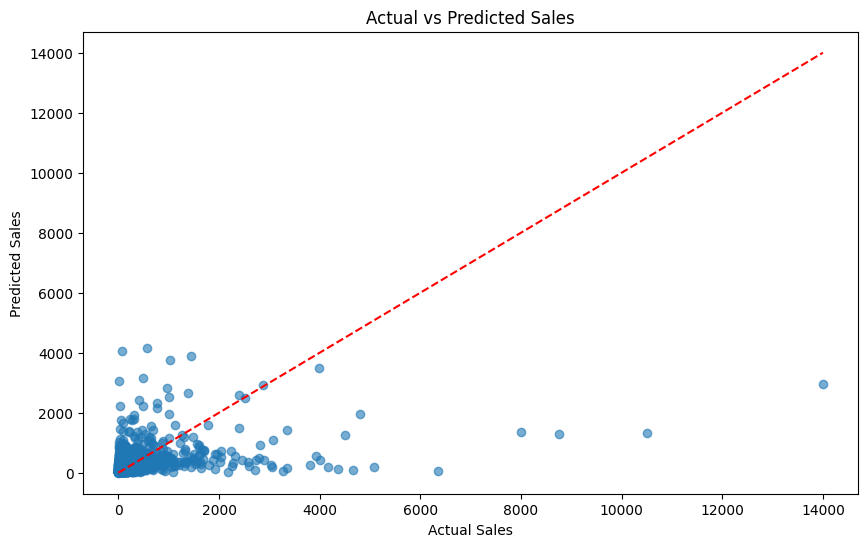

In [70]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

         Feature  Importance
7   Sub-Category    0.186671
10           Day    0.159096
3           City    0.140659
9          Month    0.113645
4          State    0.102271
8           Year    0.085192
5         Region    0.061770
6       Category    0.056123
0      Ship Mode    0.049771
1        Segment    0.044803
2        Country    0.000000


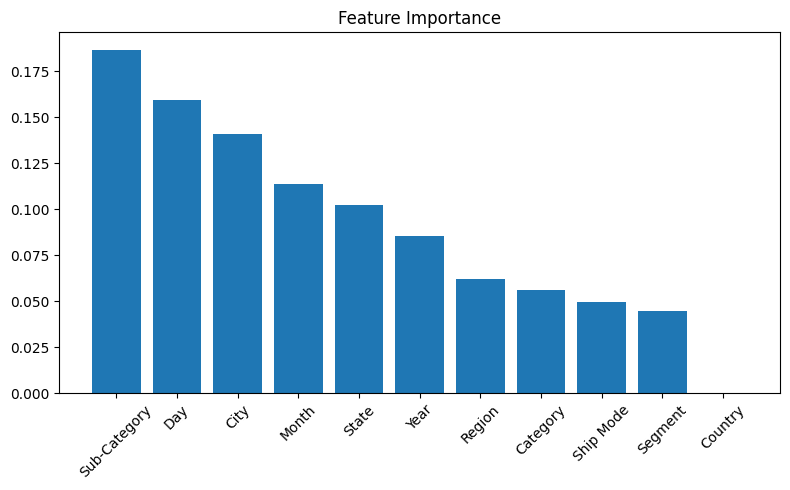

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()